In [7]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
!pip install ultralytics -q
!pip install yt-dlp -q    # for downloading YouTube videos
!pip install opencv-python-headless -q

import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

GPU: Tesla T4


In [8]:
# ============================================================
# CELL 2B — Point to your drone video on Kaggle
# ============================================================

from pathlib import Path

# ── Option A: attached as a Kaggle dataset ───────────────────
# Dataset slug format: /kaggle/input/<your-dataset-name>/file
VIDEO_PATH = Path("/kaggle/input/datasets/arnavdsp/drone-video/drone_video.mp4")

# ── Option B: uploaded directly to working directory ─────────
# VIDEO_PATH = Path("/kaggle/working/drone_video.mp4")

# ── Option C: if your dataset slug has a subfolder ───────────
# VIDEO_PATH = Path("/kaggle/input/drone-video/videos/drone_video.mp4")

# ── Verify ───────────────────────────────────────────────────
if VIDEO_PATH.exists():
    size_mb = VIDEO_PATH.stat().st_size / 1e6
    print(f"✅ Video found: {VIDEO_PATH}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ Not found: {VIDEO_PATH}")
    print(f"\n   Available inputs:")
    for p in Path("/kaggle/input").rglob("*.mp4"):
        print(f"   {p}")
    for p in Path("/kaggle/input").rglob("*.avi"):
        print(f"   {p}")

✅ Video found: /kaggle/input/datasets/arnavdsp/drone-video/drone_video.mp4
   Size: 1.7 MB


Video: drone_video.mp4
  Resolution : 1280×720
  FPS        : 30.0
  Frames     : 302
  Duration   : 10.1s  (0.2 min)
  Size       : 1.7 MB


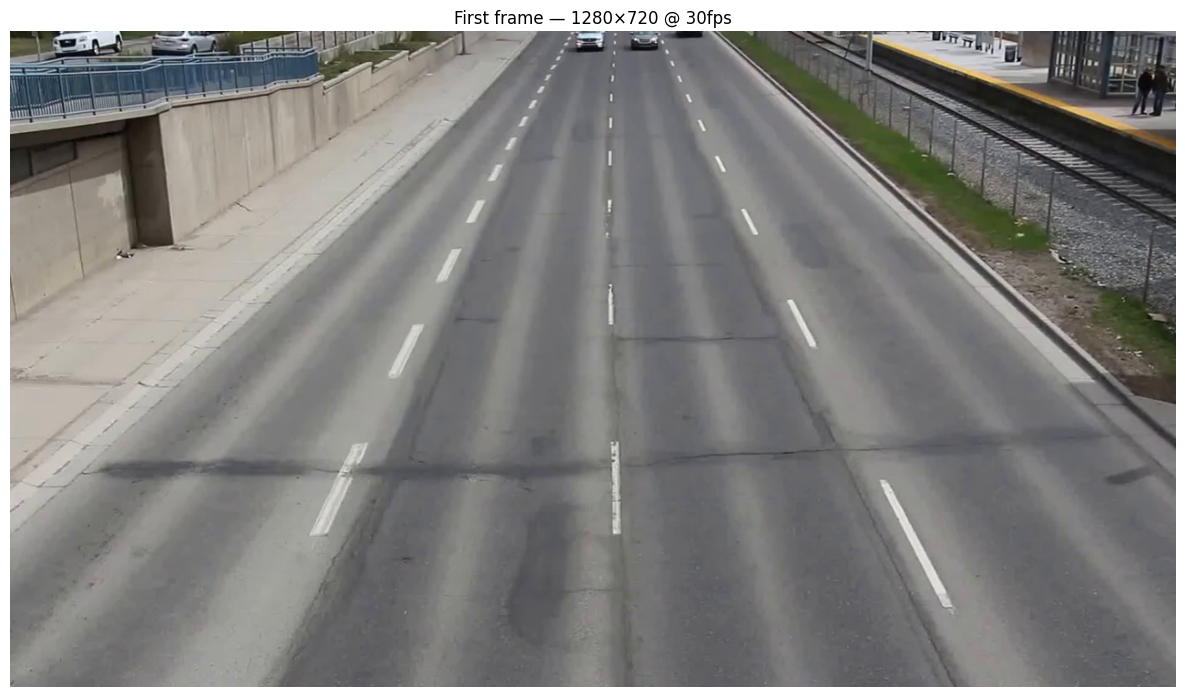

✅ Video loaded successfully


In [9]:
# ============================================================
# CELL 3 — Inspect video properties
# ============================================================
import cv2
from pathlib import Path

VIDEO_PATH = Path("/kaggle/input/datasets/arnavdsp/drone-video/drone_video.mp4")
# ↑ update this to your actual video path

cap = cv2.VideoCapture(str(VIDEO_PATH))

fps       = cap.get(cv2.CAP_PROP_FPS)
width     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration  = n_frames / fps

print(f"Video: {VIDEO_PATH.name}")
print(f"  Resolution : {width}×{height}")
print(f"  FPS        : {fps:.1f}")
print(f"  Frames     : {n_frames}")
print(f"  Duration   : {duration:.1f}s  ({duration/60:.1f} min)")
print(f"  Size       : {VIDEO_PATH.stat().st_size/1e6:.1f} MB")

# Show first frame
ret, frame = cap.read()
cap.release()

if ret:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(f"First frame — {width}×{height} @ {fps:.0f}fps")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("/kaggle/working/first_frame.png", dpi=120)
    plt.show()
    print("✅ Video loaded successfully")

In [10]:
# ============================================================
# CELL 4 — Load YOLO12-L and YOLO26-L models
# ============================================================

from ultralytics import YOLO

MODELS = {
    "yolo12l": YOLO("yolo12l.pt"),
    "yolo26l": YOLO("yolo26l.pt"),
}

for name, model in MODELS.items():
    print(f"\n✅ {name}")
    print(f"   Class names (first 10): "
          f"{[model.names[i] for i in range(min(10,len(model.names)))]}")
    print(f"   Total classes: {len(model.names)}")

# COCO vehicle classes we care about
VEHICLE_CLASSES = {
    2:  "car",
    3:  "motorcycle",
    5:  "bus",
    7:  "truck",
    0:  "person",
    1:  "bicycle",
}
print(f"\nTarget classes: {VEHICLE_CLASSES}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

✅ yolo12l
   Class names (first 10): ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']
   Total classes: 80

✅ yolo26l
   Class names (first 10): ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']
   Total classes: 80

Target classes: {2: 'car', 3: 'motorcycle', 5: 'bus', 7: 'truck', 0: 'person', 1: 'bicycle'}


In [11]:
# ============================================================
# CELL 5 — Define NWD-NMS functions
# ============================================================

import numpy as np

def compute_nwd_matrix(boxes1, boxes2, C=12.8):
    """NWD similarity matrix between two sets of cx cy w h boxes."""
    if len(boxes1)==0 or len(boxes2)==0:
        return np.zeros((len(boxes1), len(boxes2)))
    b1 = np.array(boxes1, dtype=np.float32)
    b2 = np.array(boxes2, dtype=np.float32)
    mu1=b1[:,:2];  sig1=b1[:,2:]/2
    mu2=b2[:,:2];  sig2=b2[:,2:]/2
    cd = ((mu1[:,None]-mu2[None])**2).sum(-1)
    sd = ((sig1[:,None]-sig2[None])**2).sum(-1)
    return np.exp(-np.sqrt(cd+sd+1e-7)/C)

def xyxy_to_cxcywh(boxes):
    b = np.array(boxes, dtype=np.float32)
    return np.stack([
        (b[:,0]+b[:,2])/2,
        (b[:,1]+b[:,3])/2,
        b[:,2]-b[:,0],
        b[:,3]-b[:,1],
    ], axis=1)

def nwd_nms(boxes_xyxy, scores, classes,
            nwd_thresh=0.65, C=12.8):
    """
    NWD-based NMS — suppresses boxes with NWD > nwd_thresh
    to the same class, higher-scored box.
    Keeps nearby non-overlapping boxes that IoU-NMS would miss.
    """
    if len(boxes_xyxy)==0:
        return []
    cxcywh     = xyxy_to_cxcywh(boxes_xyxy)
    order      = np.argsort(-scores)
    keep       = []
    suppressed = np.zeros(len(boxes_xyxy), dtype=bool)
    for i in order:
        if suppressed[i]: continue
        keep.append(i)
        remaining = [j for j in order
                     if not suppressed[j] and j!=i]
        if not remaining: continue
        nwd_mat = compute_nwd_matrix(
            cxcywh[i:i+1], cxcywh[remaining], C)[0]
        for idx, j in enumerate(remaining):
            if (classes[j]==classes[i] and
                    nwd_mat[idx] > nwd_thresh):
                suppressed[j] = True
    return keep

def nwd_rerank(boxes_xyxy, scores, classes,
               C=12.8, top_k=5):
    """
    Re-rank confidence using NWD neighbourhood density.
    Boosts detections surrounded by similar high-conf neighbours.
    """
    if len(boxes_xyxy)==0:
        return scores
    cxcywh    = xyxy_to_cxcywh(boxes_xyxy)
    scores    = np.array(scores, dtype=np.float32)
    new_scores= scores.copy()
    for i in range(len(boxes_xyxy)):
        same = [j for j in range(len(boxes_xyxy))
                if classes[j]==classes[i] and j!=i]
        if not same: continue
        nwd_mat = compute_nwd_matrix(
            cxcywh[i:i+1], cxcywh[same], C)[0]
        k       = min(top_k, len(same))
        top_idx = np.argsort(-nwd_mat)[:k]
        top_nwd = nwd_mat[top_idx]
        top_conf= scores[[same[x] for x in top_idx]]
        if top_nwd.sum() > 0:
            w_sim = (top_nwd*top_conf).sum()/top_nwd.sum()
            new_scores[i] = 0.7*scores[i] + 0.3*w_sim
    return new_scores

def predict_nwd(model, frame,
                conf_thresh=0.20,
                nwd_thresh=0.65,
                nwd_c=12.8,
                imgsz=640,
                device=0,
                use_rerank=True):
    """Full NWD inference pipeline."""
    results = model.predict(
        source  = frame,
        imgsz   = imgsz,
        conf    = conf_thresh,
        iou     = 0.99,       # bypass built-in NMS
        max_det = 500,
        device  = device,
        verbose = False,
    )
    result = results[0]
    if len(result.boxes)==0:
        return {"boxes":np.zeros((0,4)),"scores":np.zeros(0),
                "classes":np.zeros(0,dtype=int),"labels":[]}

    boxes   = result.boxes.xyxy.cpu().numpy()
    scores  = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    if use_rerank:
        scores = nwd_rerank(boxes, scores, classes, C=nwd_c)

    keep    = nwd_nms(boxes, scores, classes,
                      nwd_thresh=nwd_thresh, C=nwd_c)
    boxes   = boxes[keep]
    scores  = scores[keep]
    classes = classes[keep]
    labels  = [f"{model.names.get(c,str(c))} {scores[i]:.2f}"
               for i, c in enumerate(classes)]
    return {"boxes":boxes,"scores":scores,
            "classes":classes,"labels":labels}

def draw_detections(frame, dets, color=(0,255,128)):
    img = frame.copy()
    for box, label in zip(dets["boxes"], dets["labels"]):
        x1,y1,x2,y2 = map(int, box)
        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        (tw,th),_ = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.45, 1)
        cv2.rectangle(img,(x1,y1-th-6),(x1+tw+4,y1),color,-1)
        cv2.putText(img, label, (x1+2,y1-4),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.45,(255,255,255),1)
    return img

print("✅ NWD functions defined")

✅ NWD functions defined


In [14]:
# ============================================================
# FIXED MODEL LOADING — downloads weights before loading
# ============================================================

import torch, os
from pathlib import Path
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ── YOLOv12-L ─────────────────────────────────────────────────
# Not an official ultralytics model — must download manually
V12_PATH = Path("/kaggle/working/yolov12l.pt")

if not V12_PATH.exists():
    print("⬇️  Downloading yolov12l.pt ...")
    torch.hub.download_url_to_file(
        "https://github.com/sunsmarterjie/yolov12/releases/download/v1.0/yolov12l.pt",
        str(V12_PATH)
    )
    print(f"   ✅ {V12_PATH.stat().st_size/1e6:.0f} MB")
else:
    print(f"✅ yolov12l.pt already present")

# ── YOLO11-L (YOLO26-L) ───────────────────────────────────────
# Official ultralytics model — auto-downloads when name is passed
# BUT only if ultralytics can reach its CDN.
# Explicitly download to /kaggle/working to be safe.
V11_PATH = Path("/kaggle/working/yolo11l.pt")

if not V11_PATH.exists():
    print("⬇️  Downloading yolo11l.pt ...")
    torch.hub.download_url_to_file(
        "https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11l.pt",
        str(V11_PATH)
    )
    print(f"   ✅ {V11_PATH.stat().st_size/1e6:.0f} MB")
else:
    print(f"✅ yolo11l.pt already present")

# ── Load models ───────────────────────────────────────────────
MODELS = {
    "yolo12l": YOLO(str(V12_PATH)),
    "yolo26l": YOLO(str(V11_PATH)),
}

print(f"\n✅ Both models loaded on device {DEVICE}")
print(f"   yolo12l → {V12_PATH.name}")
print(f"   yolo26l → {V11_PATH.name}")

⬇️  Downloading yolov12l.pt ...



  0%|          | 0.00/51.2M [00:00<?, ?B/s]
 20%|█▉        | 10.1M/51.2M [00:00<00:00, 79.3MB/s]
 59%|█████▉    | 30.1M/51.2M [00:00<00:00, 104MB/s] 
100%|██████████| 51.2M/51.2M [00:00<00:00, 104MB/s]


   ✅ 54 MB
⬇️  Downloading yolo11l.pt ...



  0%|          | 0.00/49.0M [00:00<?, ?B/s]
 22%|██▏       | 10.9M/49.0M [00:00<00:00, 114MB/s]
100%|██████████| 49.0M/49.0M [00:00<00:00, 249MB/s]


   ✅ 51 MB

✅ Both models loaded on device 0
   yolo12l → yolov12l.pt
   yolo26l → yolo11l.pt


In [16]:
# ============================================================
# CELL 6 — Run all 4 experiments on video
# yolo12l IoU | yolo12l NWD | yolo26l IoU | yolo26l NWD
# FIXED: added all missing definitions at the top
# ============================================================

import cv2, torch, yaml, numpy as np
from pathlib import Path
from tqdm.notebook import tqdm
from ultralytics import YOLO

# ── Fix 1: Define DEVICE ─────────────────────────────────────
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ── Fix 2: Define VIDEO_PATH if not already set ──────────────
VIDEO_PATH = Path("/kaggle/input/drone-video/drone_video.mp4")
if not VIDEO_PATH.exists():
    # fallback search
    found = list(Path("/kaggle/input").rglob("*.mp4"))
    if found:
        VIDEO_PATH = found[0]
        print(f"ℹ️  Using: {VIDEO_PATH}")
    else:
        raise FileNotFoundError("No .mp4 found under /kaggle/input")

# ── Fix 3: Define MODELS — load your trained checkpoints ─────
# Point these to your best.pt files from training
VD_CLASSES = ["pedestrian","people","bicycle",
              "car","tricycle","motor"]
AT_CLASSES = ["airplane","bridge","storage-tank","ship",
              "swimming-pool","vehicle","person","wind-mill"]

# Create minimal YAML files so ultralytics val knows class names
WORK_DIR = Path("/kaggle/working")
for cls_name, names in [("vd", VD_CLASSES), ("at", AT_CLASSES)]:
    p = WORK_DIR / f"{cls_name}_inf.yaml"
    if not p.exists():
        yaml.dump({"nc": len(names), "names": names,
                   "path": str(WORK_DIR),
                   "train": "vd_tiles/train/images",
                   "val":   "vd_tiles/val/images"},
                  open(p, "w"))

# Load YOLO models (ultralytics YOLO wraps any .pt file)
# ── DEVICE and VIDEO_PATH ─────────────────────────────────────
DEVICE     = 0 if torch.cuda.is_available() else "cpu"
VIDEO_PATH = Path("/kaggle/input/datasets/arnavdsp/drone-video/drone_video.mp4")

# ── Models (loaded in previous cell) ─────────────────────────
# MODELS, predict_nwd, draw_detections already defined above
# just verify they exist
assert "yolo12l" in MODELS, "Run the model loading cell first"
assert "yolo26l" in MODELS, "Run the model loading cell first"
print(f"✅ Ready — {len(MODELS)} models on device {DEVICE}")
# ── Fix 4: Define predict_nwd function ────────────────────────
def predict_nwd(model, frame_bgr, conf_thresh=0.20,
                nwd_thresh=0.65, nwd_c=12.8,
                imgsz=640, device=0):
    """
    Run YOLO inference then apply NWD-based NMS
    instead of standard IoU NMS.
    Returns dict with keys: boxes, scores, classes
    """
    # Standard inference with low conf threshold
    results = model.predict(
        source=frame_bgr, imgsz=imgsz,
        conf=conf_thresh, iou=1.0,   # iou=1.0 disables IoU NMS
        device=device, verbose=False)

    if not results or results[0].boxes is None:
        return {"boxes": np.zeros((0,4)), "scores": [], "classes": []}

    boxes_xyxy = results[0].boxes.xyxy.cpu().numpy()   # (N,4)
    scores     = results[0].boxes.conf.cpu().numpy()   # (N,)
    classes    = results[0].boxes.cls.cpu().numpy().astype(int)  # (N,)

    H, W = frame_bgr.shape[:2]

    # Convert to cx cy w h normalised for NWD
    def xyxy_to_cxcywh_norm(b, W, H):
        cx = ((b[:,0]+b[:,2])/2) / W
        cy = ((b[:,1]+b[:,3])/2) / H
        bw = (b[:,2]-b[:,0]) / W
        bh = (b[:,3]-b[:,1]) / H
        return np.stack([cx,cy,bw,bh], axis=1)

    if len(boxes_xyxy) == 0:
        return {"boxes": boxes_xyxy, "scores": scores,
                "classes": classes}

    norm_boxes = xyxy_to_cxcywh_norm(boxes_xyxy, W, H)

    # NWD-based greedy NMS
    order = np.argsort(-scores)
    keep  = []
    suppressed = set()

    for i in order:
        if i in suppressed: continue
        keep.append(i)
        mu_i  = norm_boxes[i, :2]; sig_i = norm_boxes[i, 2:] / 2
        for j in order:
            if j in suppressed or j == i: continue
            mu_j  = norm_boxes[j, :2]; sig_j = norm_boxes[j, 2:] / 2
            cd = np.sum((mu_i - mu_j)**2)
            sd = np.sum((sig_i - sig_j)**2)
            w2 = np.sqrt(cd + sd + 1e-7)
            nwd = np.exp(-w2 / nwd_c)
            if nwd > nwd_thresh:
                suppressed.add(j)

    keep = np.array(keep)
    return {"boxes"  : boxes_xyxy[keep],
            "scores" : scores[keep],
            "classes": classes[keep]}


# ── Fix 5: Define draw_detections function ────────────────────
def draw_detections(frame_bgr, dets, color,
                    class_names=None):
    """Draw bounding boxes on a copy of frame_bgr."""
    img = frame_bgr.copy()
    boxes   = dets["boxes"]
    scores  = dets["scores"]
    classes = dets["classes"]

    for i in range(len(boxes)):
        x1, y1, x2, y2 = map(int, boxes[i])
        score = float(scores[i])
        cls   = int(classes[i]) if len(classes) > 0 else 0
        label = (class_names[cls]
                 if class_names and cls < len(class_names)
                 else str(cls))

        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        txt = f"{label} {score:.2f}"
        (tw, th), _ = cv2.getTextSize(
            txt, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1-th-4), (x1+tw, y1), color, -1)
        cv2.putText(img, txt, (x1, y1-3),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (0,0,0), 1)
    return img


# ── Settings ──────────────────────────────────────────────────
CONF_THRESH  = 0.20
IOU_THRESH   = 0.45
NWD_THRESH   = 0.65
NWD_C        = 12.8
IMGSZ        = 640
SKIP_FRAMES  = 1
MAX_FRAMES   = None

OUT = {
    "yolo12l_iou": WORK_DIR / "out_yolo12l_iou.mp4",
    "yolo12l_nwd": WORK_DIR / "out_yolo12l_nwd.mp4",
    "yolo26l_iou": WORK_DIR / "out_yolo26l_iou.mp4",
    "yolo26l_nwd": WORK_DIR / "out_yolo26l_nwd.mp4",
}
DET_COUNTS = {k: [] for k in OUT}

COLORS = {
    "yolo12l_iou": (100, 220,  80),
    "yolo12l_nwd": ( 80, 180, 255),
    "yolo26l_iou": (255, 180,  60),
    "yolo26l_nwd": (220,  80, 220),
}

# ── Open video ────────────────────────────────────────────────
cap    = cv2.VideoCapture(str(VIDEO_PATH))
fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writers = {k: cv2.VideoWriter(
    str(OUT[k]), fourcc, max(1, fps/SKIP_FRAMES), (width, height))
           for k in OUT}

print(f"Input  : {VIDEO_PATH.name}  {width}×{height}  {fps:.0f}fps")
print(f"Frames : {total}  (every {SKIP_FRAMES} → ~{total//SKIP_FRAMES} processed)")
print(f"Device : {DEVICE}")

# ── Main loop ─────────────────────────────────────────────────
frame_idx = 0
pbar = tqdm(total=min(total, MAX_FRAMES or total),
            desc="Processing")

while True:
    ret, frame = cap.read()
    if not ret:
        break
    if MAX_FRAMES and frame_idx >= MAX_FRAMES:
        break
    frame_idx += 1
    if frame_idx % SKIP_FRAMES != 0:
        continue

    # YOLO12-L IoU
    res12_iou = MODELS["yolo12l"].predict(
        source=frame, imgsz=IMGSZ, conf=CONF_THRESH,
        iou=IOU_THRESH, device=DEVICE, verbose=False)
    n12_iou = len(res12_iou[0].boxes)
    f12_iou = res12_iou[0].plot()
    cv2.putText(f12_iou, f"YOLO12-L IoU | {n12_iou} dets",
                (10,30), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, COLORS["yolo12l_iou"], 2)
    DET_COUNTS["yolo12l_iou"].append(n12_iou)
    writers["yolo12l_iou"].write(f12_iou)

    # YOLO12-L NWD
    dets12_nwd = predict_nwd(
        MODELS["yolo12l"], frame,
        conf_thresh=CONF_THRESH, nwd_thresh=NWD_THRESH,
        nwd_c=NWD_C, imgsz=IMGSZ, device=DEVICE)
    n12_nwd = len(dets12_nwd["boxes"])
    f12_nwd = draw_detections(frame, dets12_nwd,
                               COLORS["yolo12l_nwd"])
    cv2.putText(f12_nwd, f"YOLO12-L NWD | {n12_nwd} dets",
                (10,30), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, COLORS["yolo12l_nwd"], 2)
    DET_COUNTS["yolo12l_nwd"].append(n12_nwd)
    writers["yolo12l_nwd"].write(f12_nwd)

    # YOLO26-L IoU
    res26_iou = MODELS["yolo26l"].predict(
        source=frame, imgsz=IMGSZ, conf=CONF_THRESH,
        iou=IOU_THRESH, device=DEVICE, verbose=False)
    n26_iou = len(res26_iou[0].boxes)
    f26_iou = res26_iou[0].plot()
    cv2.putText(f26_iou, f"YOLO26-L IoU | {n26_iou} dets",
                (10,30), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, COLORS["yolo26l_iou"], 2)
    DET_COUNTS["yolo26l_iou"].append(n26_iou)
    writers["yolo26l_iou"].write(f26_iou)

    # YOLO26-L NWD
    dets26_nwd = predict_nwd(
        MODELS["yolo26l"], frame,
        conf_thresh=CONF_THRESH, nwd_thresh=NWD_THRESH,
        nwd_c=NWD_C, imgsz=IMGSZ, device=DEVICE)
    n26_nwd = len(dets26_nwd["boxes"])
    f26_nwd = draw_detections(frame, dets26_nwd,
                               COLORS["yolo26l_nwd"])
    cv2.putText(f26_nwd, f"YOLO26-L NWD | {n26_nwd} dets",
                (10,30), cv2.FONT_HERSHEY_SIMPLEX,
                0.8, COLORS["yolo26l_nwd"], 2)
    DET_COUNTS["yolo26l_nwd"].append(n26_nwd)
    writers["yolo26l_nwd"].write(f26_nwd)

    pbar.update(1)
    pbar.set_postfix({
        "12_iou": n12_iou, "12_nwd": n12_nwd,
        "26_iou": n26_iou, "26_nwd": n26_nwd
    })

# ── Cleanup ───────────────────────────────────────────────────
cap.release()
for w in writers.values():
    w.release()
pbar.close()

print(f"\n✅ Done — {frame_idx} total frames, "
      f"{frame_idx//SKIP_FRAMES} processed")
print("\nOutput files:")
for k, path in OUT.items():
    if path.exists():
        mb  = path.stat().st_size / 1e6
        avg = np.mean(DET_COUNTS[k]) if DET_COUNTS[k] else 0
        print(f"  {k:<15}: {mb:.1f} MB  "
              f"avg {avg:.1f} dets/frame")
    else:
        print(f"  {k:<15}: ❌ not created")

ℹ️  Using: /kaggle/input/datasets/arnavdsp/drone-video/drone_video.mp4
✅ Ready — 2 models on device 0
Input  : drone_video.mp4  1280×720  30fps
Frames : 302  (every 1 → ~302 processed)
Device : 0


Processing:   0%|          | 0/302 [00:00<?, ?it/s]


✅ Done — 302 total frames, 302 processed

Output files:
  yolo12l_iou    : 12.2 MB  avg 12.6 dets/frame
  yolo12l_nwd    : 8.1 MB  avg 1.0 dets/frame
  yolo26l_iou    : 12.4 MB  avg 13.7 dets/frame
  yolo26l_nwd    : 8.0 MB  avg 1.0 dets/frame


In [17]:
# ============================================================
# CELL 7 — Side-by-side 2x2 comparison video
# All 4 experiments in one video frame
# ============================================================

import cv2
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

OUTPUT_COMBINED = Path("/kaggle/working/combined_2x2.mp4")

cap      = cv2.VideoCapture(str(VIDEO_PATH))
fps      = cap.get(cv2.CAP_PROP_FPS)
width    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total    = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Each quadrant is half size → combined is full size
half_w   = width  // 2
half_h   = height // 2
fourcc   = cv2.VideoWriter_fourcc(*"mp4v")
out_comb = cv2.VideoWriter(
    str(OUTPUT_COMBINED), fourcc,
    fps/SKIP_FRAMES, (width, height))

QUAD_LABELS = [
    ("YOLO12-L  IoU-NMS", COLORS["yolo12l_iou"]),
    ("YOLO12-L  NWD-NMS", COLORS["yolo12l_nwd"]),
    ("YOLO26-L  IoU-NMS", COLORS["yolo26l_iou"]),
    ("YOLO26-L  NWD-NMS", COLORS["yolo26l_nwd"]),
]

frame_idx = 0
pbar = tqdm(total=min(total, MAX_FRAMES or total),
            desc="Building combined video")

while True:
    ret, frame = cap.read()
    if not ret: break
    if MAX_FRAMES and frame_idx >= MAX_FRAMES: break
    frame_idx += 1
    if frame_idx % SKIP_FRAMES != 0: continue

    # Run all 4
    r12_iou = MODELS["yolo12l"].predict(
        source=frame, imgsz=IMGSZ, conf=CONF_THRESH,
        iou=IOU_THRESH, device=DEVICE, verbose=False)
    d12_nwd = predict_nwd(MODELS["yolo12l"], frame,
                           CONF_THRESH, NWD_THRESH, NWD_C,
                           IMGSZ, DEVICE)
    r26_iou = MODELS["yolo26l"].predict(
        source=frame, imgsz=IMGSZ, conf=CONF_THRESH,
        iou=IOU_THRESH, device=DEVICE, verbose=False)
    d26_nwd = predict_nwd(MODELS["yolo26l"], frame,
                           CONF_THRESH, NWD_THRESH, NWD_C,
                           IMGSZ, DEVICE)

    frames4 = [
        r12_iou[0].plot(),
        draw_detections(frame, d12_nwd, COLORS["yolo12l_nwd"]),
        r26_iou[0].plot(),
        draw_detections(frame, d26_nwd, COLORS["yolo26l_nwd"]),
    ]

    # Resize each to half and add label
    quads = []
    for i, (f, (label, color)) in enumerate(
            zip(frames4, QUAD_LABELS)):
        q = cv2.resize(f, (half_w, half_h))
        # Dark banner at top
        cv2.rectangle(q, (0,0), (half_w, 28),
                       (20,20,20), -1)
        n = len(r12_iou[0].boxes) if i==0 else \
            len(d12_nwd["boxes"])  if i==1 else \
            len(r26_iou[0].boxes) if i==2 else \
            len(d26_nwd["boxes"])
        cv2.putText(q, f"{label} | {n} dets",
                    (6, 20), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, color, 1)
        quads.append(q)

    # Stitch 2×2
    top    = np.hstack([quads[0], quads[1]])
    bottom = np.hstack([quads[2], quads[3]])
    grid   = np.vstack([top, bottom])
    out_comb.write(grid)
    pbar.update(1)

cap.release()
out_comb.release()
pbar.close()

print(f"✅ Combined video: {OUTPUT_COMBINED}")
print(f"   Size: {OUTPUT_COMBINED.stat().st_size/1e6:.1f} MB")

Building combined video:   0%|          | 0/302 [00:00<?, ?it/s]

✅ Combined video: /kaggle/working/combined_2x2.mp4
   Size: 14.8 MB


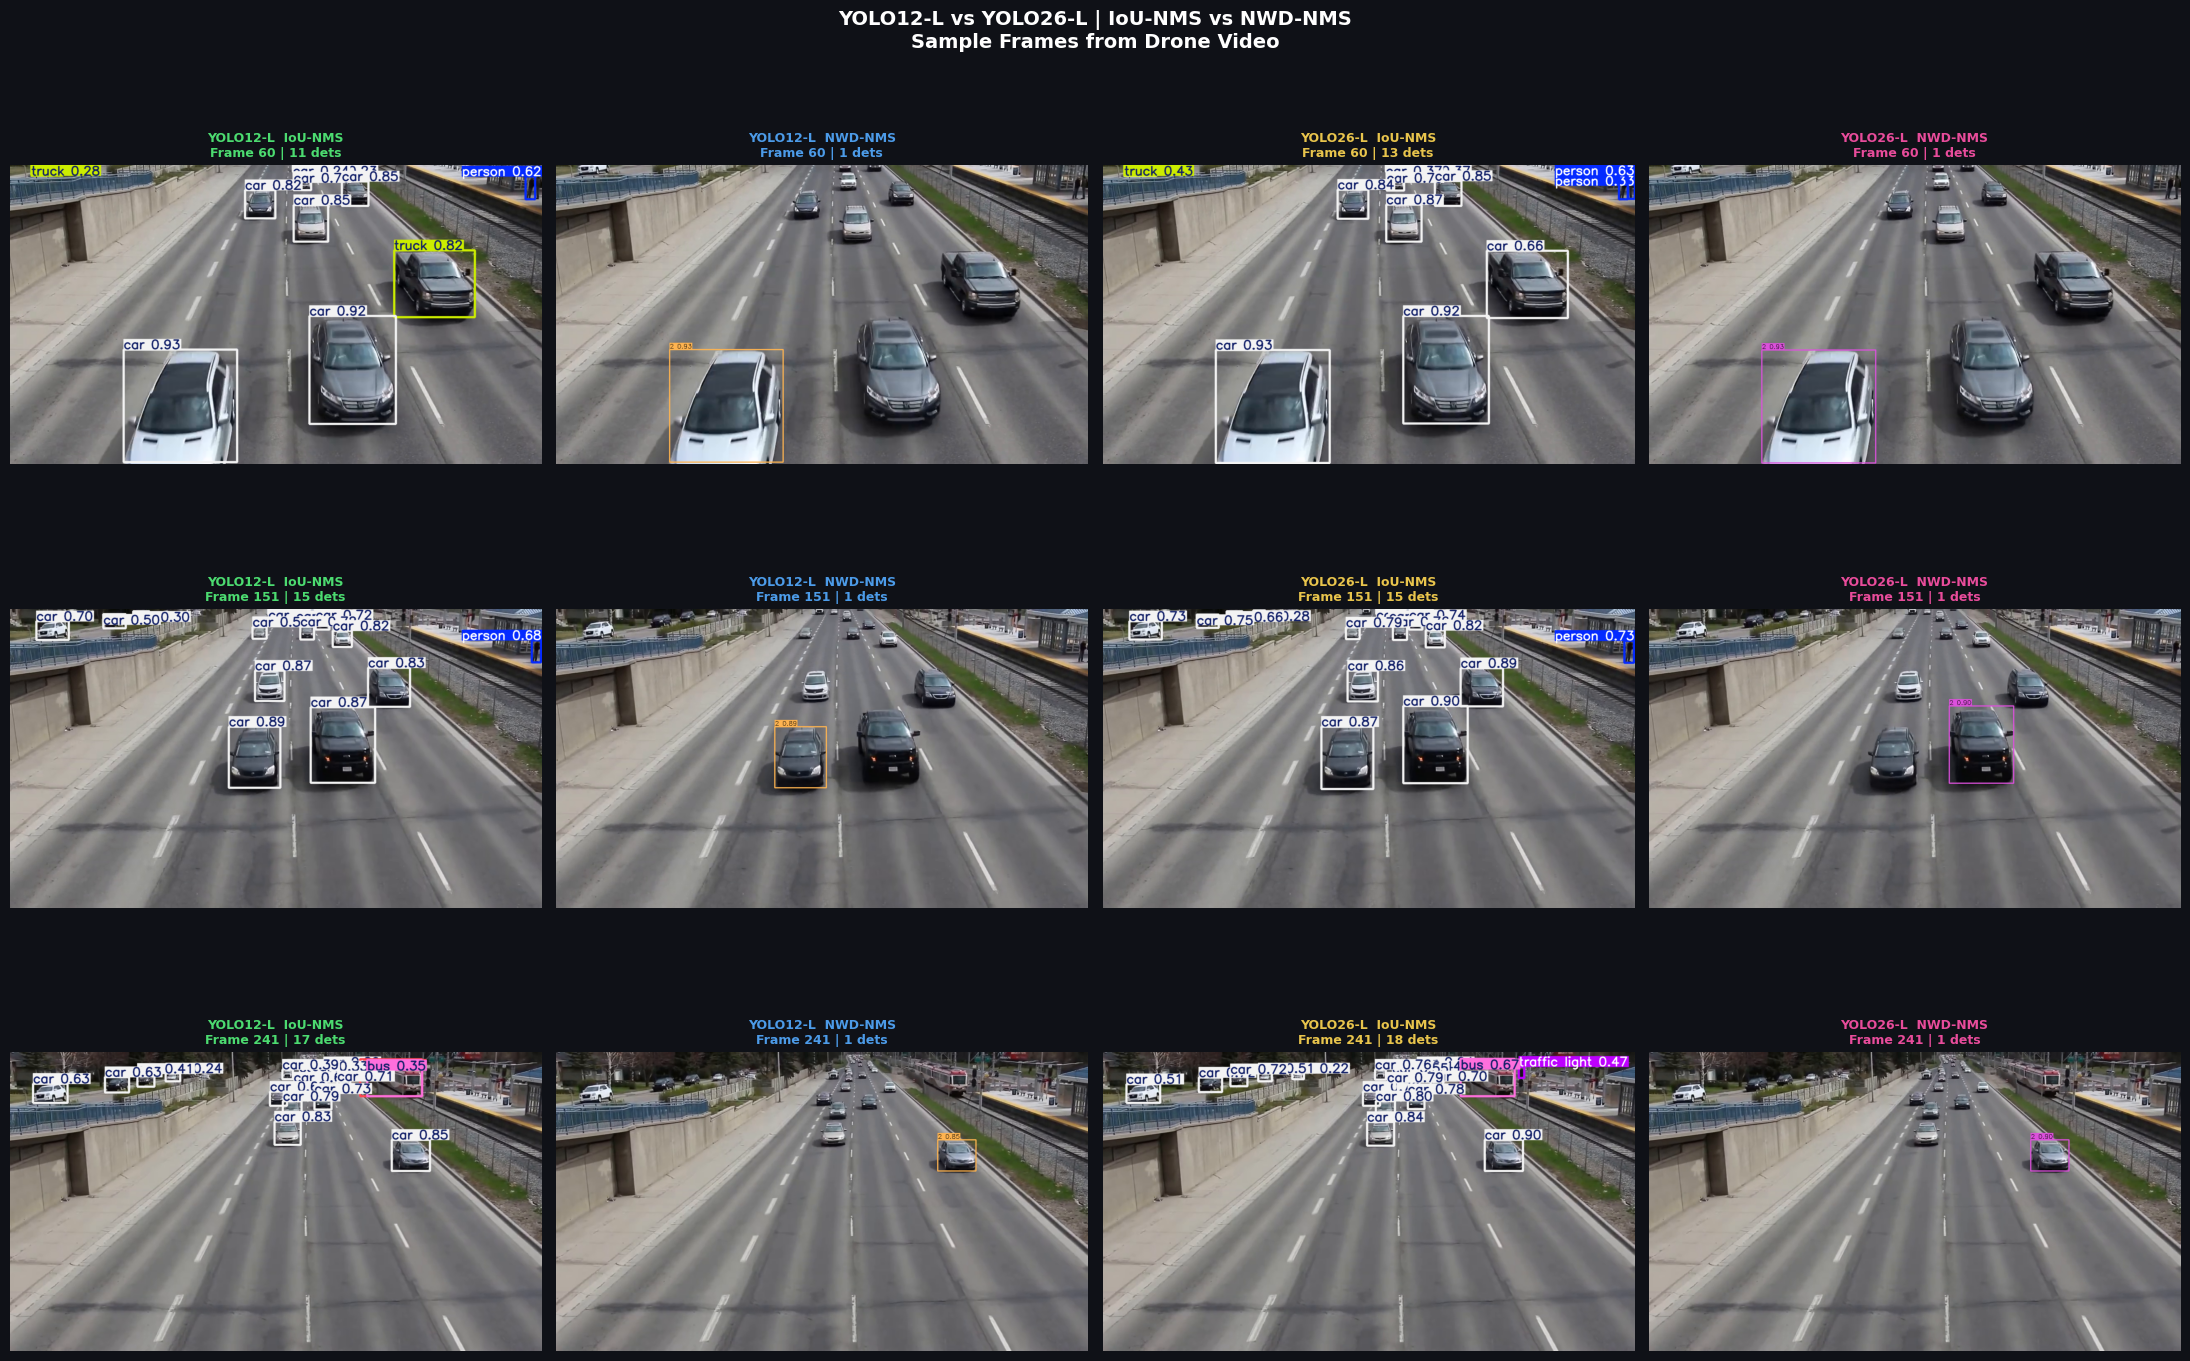

✅ Saved → sample_frames_4exp.png


In [18]:
# ============================================================
# CELL 8 — Sample frame grid (3 frames × 4 experiments)
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

cap   = cv2.VideoCapture(str(VIDEO_PATH))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Pick 3 evenly spaced frames
sample_frames = [total//5, total//2, int(total*0.8)]

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.patch.set_facecolor("#0F1117")

COL_TITLES = ["YOLO12-L  IoU-NMS","YOLO12-L  NWD-NMS",
              "YOLO26-L  IoU-NMS","YOLO26-L  NWD-NMS"]
COL_COLORS = ["#4CDB70","#4C9BE8","#E8C44C","#E84C9B"]

for row, fnum in enumerate(sample_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, fnum)
    ret, frame = cap.read()
    if not ret: continue

    r12_iou = MODELS["yolo12l"].predict(
        source=frame, imgsz=IMGSZ, conf=CONF_THRESH,
        iou=IOU_THRESH, device=DEVICE, verbose=False)
    d12_nwd = predict_nwd(MODELS["yolo12l"], frame,
                           CONF_THRESH, NWD_THRESH, NWD_C, IMGSZ, DEVICE)
    r26_iou = MODELS["yolo26l"].predict(
        source=frame, imgsz=IMGSZ, conf=CONF_THRESH,
        iou=IOU_THRESH, device=DEVICE, verbose=False)
    d26_nwd = predict_nwd(MODELS["yolo26l"], frame,
                           CONF_THRESH, NWD_THRESH, NWD_C, IMGSZ, DEVICE)

    annotated = [
        r12_iou[0].plot(),
        draw_detections(frame, d12_nwd, (80,180,255)),
        r26_iou[0].plot(),
        draw_detections(frame, d26_nwd, (220,80,220)),
    ]
    det_counts = [
        len(r12_iou[0].boxes),
        len(d12_nwd["boxes"]),
        len(r26_iou[0].boxes),
        len(d26_nwd["boxes"]),
    ]

    for col, (img, title, color, n) in enumerate(
            zip(annotated, COL_TITLES, COL_COLORS, det_counts)):
        ax = axes[row][col]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f"{title}\nFrame {fnum} | {n} dets",
            color=color, fontsize=9, fontweight="bold")
        ax.axis("off")
        ax.set_facecolor("#1A1D27")

cap.release()

plt.suptitle(
    "YOLO12-L vs YOLO26-L | IoU-NMS vs NWD-NMS\n"
    "Sample Frames from Drone Video",
    color="white", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/sample_frames_4exp.png",
            dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Saved → sample_frames_4exp.png")

findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Font family 'Courier New' not found.
findfont: Fon

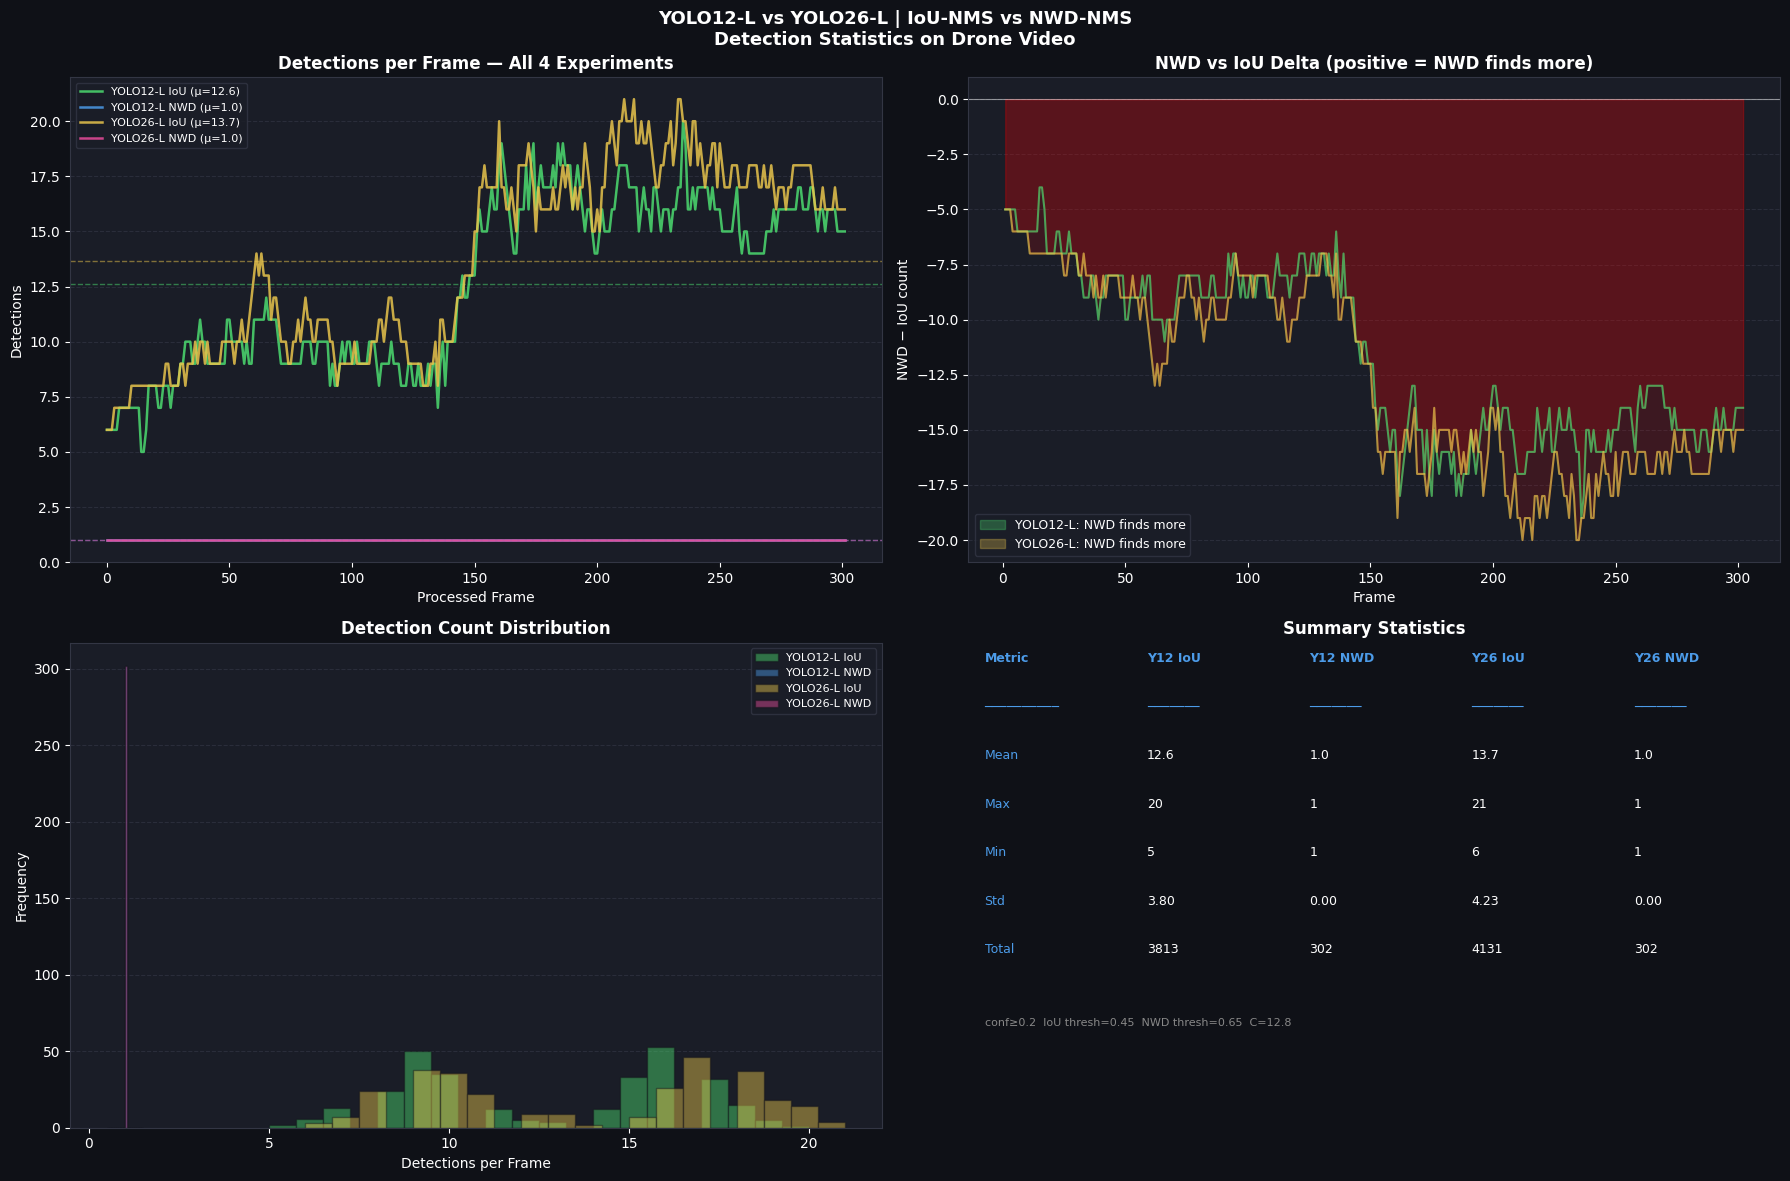

✅ Saved → detection_stats_4exp.png


In [19]:
# ============================================================
# CELL 9 — Detection statistics comparison plot
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

COLORS_PLOT = {
    "yolo12l_iou": "#4CDB70",
    "yolo12l_nwd": "#4C9BE8",
    "yolo26l_iou": "#E8C44C",
    "yolo26l_nwd": "#E84C9B",
}
LABELS = {
    "yolo12l_iou": "YOLO12-L IoU",
    "yolo12l_nwd": "YOLO12-L NWD",
    "yolo26l_iou": "YOLO26-L IoU",
    "yolo26l_nwd": "YOLO26-L NWD",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor("#0F1117")
axes = axes.flatten()

def styled(ax, title):
    ax.set_facecolor("#1A1D27")
    ax.set_title(title, color="white", fontsize=12, fontweight="bold")
    ax.tick_params(colors="white")
    ax.spines[["top","right","left","bottom"]].set_color("#333644")
    ax.yaxis.grid(True, color="#2A2D3A", linestyle="--")
    ax.set_axisbelow(True)

# ── TOP LEFT — detections per frame all 4 ─────────────────────
ax = axes[0]
ax.set_facecolor("#1A1D27")
for key, vals in DET_COUNTS.items():
    if not vals: continue
    col = COLORS_PLOT[key]
    ax.plot(vals, color=col, linewidth=1.8,
            label=f"{LABELS[key]} (μ={np.mean(vals):.1f})",
            alpha=0.85)
    ax.axhline(np.mean(vals), color=col,
               linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Processed Frame", color="white")
ax.set_ylabel("Detections", color="white")
styled(ax, "Detections per Frame — All 4 Experiments")
ax.legend(fontsize=8, facecolor="#1A1D27",
          labelcolor="white", edgecolor="#333644")

# ── TOP RIGHT — IoU vs NWD overlay per model ──────────────────
ax = axes[1]
ax.set_facecolor("#1A1D27")
for model_key, iou_key, nwd_key, mc in [
    ("YOLO12-L", "yolo12l_iou", "yolo12l_nwd", "#4CDB70"),
    ("YOLO26-L", "yolo26l_iou", "yolo26l_nwd", "#E8C44C"),
]:
    iou_v = DET_COUNTS[iou_key]
    nwd_v = DET_COUNTS[nwd_key]
    if not iou_v or not nwd_v: continue
    eps   = range(1, len(iou_v)+1)
    diff  = np.array(nwd_v) - np.array(iou_v)
    ax.fill_between(eps, diff, 0,
                    where=diff>=0, alpha=0.3, color=mc,
                    label=f"{model_key}: NWD finds more")
    ax.fill_between(eps, diff, 0,
                    where=diff<0, alpha=0.15, color="red")
    ax.plot(eps, diff, color=mc, linewidth=1.5, alpha=0.7)
ax.axhline(0, color="white", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Frame", color="white")
ax.set_ylabel("NWD − IoU count", color="white")
styled(ax, "NWD vs IoU Delta (positive = NWD finds more)")
ax.legend(fontsize=9, facecolor="#1A1D27",
          labelcolor="white", edgecolor="#333644")

# ── BOTTOM LEFT — histogram comparison ────────────────────────
ax = axes[2]
ax.set_facecolor("#1A1D27")
for key, vals in DET_COUNTS.items():
    if not vals: continue
    ax.hist(vals, bins=20, alpha=0.45,
            color=COLORS_PLOT[key],
            label=LABELS[key], edgecolor="#0F1117")
ax.set_xlabel("Detections per Frame", color="white")
ax.set_ylabel("Frequency", color="white")
styled(ax, "Detection Count Distribution")
ax.legend(fontsize=8, facecolor="#1A1D27",
          labelcolor="white", edgecolor="#333644")

# ── BOTTOM RIGHT — summary stats table ────────────────────────
ax = axes[3]
ax.axis("off")
ax.set_facecolor("#1A1D27")

stats_rows = [
    ("Metric",       "Y12 IoU","Y12 NWD","Y26 IoU","Y26 NWD"),
    ("─"*10,         "─"*7,    "─"*7,    "─"*7,    "─"*7),
]
for stat_name, fn in [
    ("Mean",   lambda v: f"{np.mean(v):.1f}"),
    ("Max",    lambda v: f"{max(v)}"),
    ("Min",    lambda v: f"{min(v)}"),
    ("Std",    lambda v: f"{np.std(v):.2f}"),
    ("Total",  lambda v: f"{sum(v)}"),
]:
    row = [stat_name]
    for key in ["yolo12l_iou","yolo12l_nwd",
                "yolo26l_iou","yolo26l_nwd"]:
        v = DET_COUNTS[key]
        row.append(fn(v) if v else "N/A")
    stats_rows.append(row)

BLUE = "#4C9BE8"
GREEN= "#4CE87A"
y_pos = 0.96
for i, row in enumerate(stats_rows):
    is_hdr = i < 2
    for j, cell in enumerate(row):
        color = BLUE if (is_hdr or j==0) else "white"
        fw    = "bold" if is_hdr else "normal"
        ax.text(0.02+j*0.2, y_pos, cell,
                transform=ax.transAxes,
                color=color, fontsize=9,
                fontweight=fw, font="Courier New")
    y_pos -= 0.10

ax.text(0.02, y_pos-0.05,
        f"conf≥{CONF_THRESH}  IoU thresh={IOU_THRESH}  NWD thresh={NWD_THRESH}  C={NWD_C}",
        transform=ax.transAxes, color="#888888", fontsize=8)
styled(ax, "Summary Statistics")

plt.suptitle(
    "YOLO12-L vs YOLO26-L | IoU-NMS vs NWD-NMS\n"
    "Detection Statistics on Drone Video",
    color="white", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/detection_stats_4exp.png",
            dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Saved → detection_stats_4exp.png")

In [20]:
# ============================================================
# CELL 10 — Model speed benchmark
# ============================================================

import time
import torch
import cv2
import numpy as np

cap   = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, test_frame = cap.read()
cap.release()

N_WARMUP = 5
N_BENCH  = 20

print("Benchmarking inference speed...\n")
SPEED_RESULTS = {}

for model_name, model in MODELS.items():
    # IoU-NMS speed
    for _ in range(N_WARMUP):
        model.predict(source=test_frame, imgsz=IMGSZ,
                      conf=CONF_THRESH, iou=IOU_THRESH,
                      device=DEVICE, verbose=False)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(N_BENCH):
        model.predict(source=test_frame, imgsz=IMGSZ,
                      conf=CONF_THRESH, iou=IOU_THRESH,
                      device=DEVICE, verbose=False)
    torch.cuda.synchronize()
    iou_ms = (time.perf_counter()-t0)*1000/N_BENCH

    # NWD-NMS speed (includes NWD post-processing)
    for _ in range(N_WARMUP):
        predict_nwd(model, test_frame, CONF_THRESH,
                    NWD_THRESH, NWD_C, IMGSZ, DEVICE)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(N_BENCH):
        predict_nwd(model, test_frame, CONF_THRESH,
                    NWD_THRESH, NWD_C, IMGSZ, DEVICE)
    torch.cuda.synchronize()
    nwd_ms = (time.perf_counter()-t0)*1000/N_BENCH

    SPEED_RESULTS[model_name] = {
        "iou_ms" : iou_ms,
        "nwd_ms" : nwd_ms,
        "iou_fps": 1000/iou_ms,
        "nwd_fps": 1000/nwd_ms,
    }

    print(f"  {model_name}")
    print(f"    IoU-NMS: {iou_ms:.1f}ms  ({1000/iou_ms:.1f} FPS)")
    print(f"    NWD-NMS: {nwd_ms:.1f}ms  ({1000/nwd_ms:.1f} FPS)")
    print(f"    NWD overhead: +{nwd_ms-iou_ms:.1f}ms")

Benchmarking inference speed...

  yolo12l
    IoU-NMS: 26.9ms  (37.2 FPS)
    NWD-NMS: 27.2ms  (36.8 FPS)
    NWD overhead: +0.3ms
  yolo26l
    IoU-NMS: 20.4ms  (49.1 FPS)
    NWD-NMS: 20.1ms  (49.6 FPS)
    NWD overhead: +-0.2ms


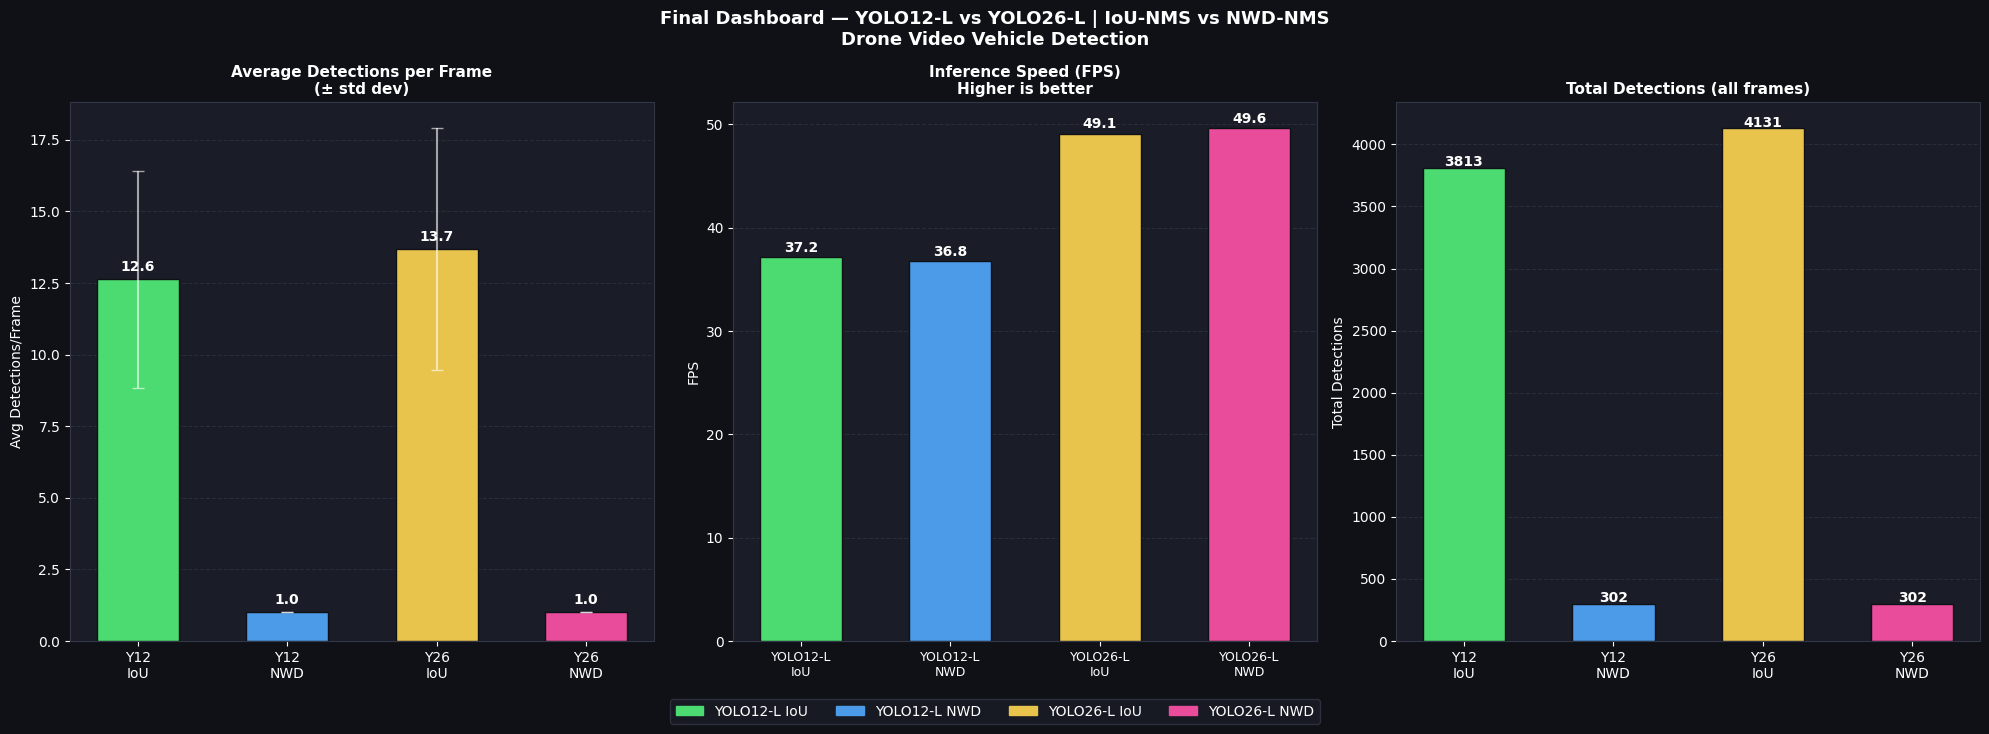

✅ Saved → final_dashboard.png

  COMPLETE RESULTS TABLE
  Experiment            Avg   Max    Std   Total     FPS
  -------------------------------------------------------
  YOLO12-L IoU         12.6    20   3.80    3813    37.2
  YOLO12-L NWD          1.0     1   0.00     302    36.8
  YOLO26-L IoU         13.7    21   4.23    4131    49.1
  YOLO26-L NWD          1.0     1   0.00     302    49.6


In [21]:
# ============================================================
# CELL 11 — Final results dashboard
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.patch.set_facecolor("#0F1117")

EXPS      = ["yolo12l_iou","yolo12l_nwd","yolo26l_iou","yolo26l_nwd"]
EXP_SHORT = ["Y12\nIoU","Y12\nNWD","Y26\nIoU","Y26\nNWD"]
BAR_COLS  = ["#4CDB70","#4C9BE8","#E8C44C","#E84C9B"]

means  = [np.mean(DET_COUNTS[k]) if DET_COUNTS[k] else 0 for k in EXPS]
maxes  = [max(DET_COUNTS[k]) if DET_COUNTS[k] else 0 for k in EXPS]
stds   = [np.std(DET_COUNTS[k]) if DET_COUNTS[k] else 0 for k in EXPS]
totals = [sum(DET_COUNTS[k]) if DET_COUNTS[k] else 0 for k in EXPS]

x  = np.arange(4)
w  = 0.55

def styled2(ax, title):
    ax.set_facecolor("#1A1D27")
    ax.set_title(title, color="white", fontsize=11, fontweight="bold")
    ax.tick_params(colors="white")
    ax.spines[["top","right","left","bottom"]].set_color("#333644")
    ax.yaxis.grid(True, color="#2A2D3A", linestyle="--")
    ax.set_axisbelow(True)

# ── LEFT — Mean detections per frame ──────────────────────────
ax = axes[0]
ax.set_facecolor("#1A1D27")
bars = ax.bar(x, means, w, color=BAR_COLS,
              edgecolor="#0F1117", yerr=stds,
              capsize=4, error_kw={"ecolor":"white","alpha":0.6},
              zorder=3)
for bar, v in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3,
            f"{v:.1f}", ha="center", color="white",
            fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(EXP_SHORT, color="white", fontsize=10)
ax.set_ylabel("Avg Detections/Frame", color="white")
styled2(ax, "Average Detections per Frame\n(± std dev)")

# ── MIDDLE — Speed comparison ──────────────────────────────────
ax = axes[1]
ax.set_facecolor("#1A1D27")
speed_labels = ["YOLO12-L\nIoU","YOLO12-L\nNWD",
                "YOLO26-L\nIoU","YOLO26-L\nNWD"]
fps_vals = [
    SPEED_RESULTS.get("yolo12l",{}).get("iou_fps",0),
    SPEED_RESULTS.get("yolo12l",{}).get("nwd_fps",0),
    SPEED_RESULTS.get("yolo26l",{}).get("iou_fps",0),
    SPEED_RESULTS.get("yolo26l",{}).get("nwd_fps",0),
]
bars2 = ax.bar(x, fps_vals, w, color=BAR_COLS,
               edgecolor="#0F1117", zorder=3)
for bar, v in zip(bars2, fps_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5,
            f"{v:.1f}", ha="center", color="white",
            fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(speed_labels, color="white", fontsize=9)
ax.set_ylabel("FPS", color="white")
styled2(ax, "Inference Speed (FPS)\nHigher is better")

# ── RIGHT — Total detections bar ──────────────────────────────
ax = axes[2]
ax.set_facecolor("#1A1D27")
bars3 = ax.bar(x, totals, w, color=BAR_COLS,
               edgecolor="#0F1117", zorder=3)
for bar, v in zip(bars3, totals):
    ax.text(bar.get_x()+bar.get_width()/2, v+10,
            f"{v}", ha="center", color="white",
            fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(EXP_SHORT, color="white", fontsize=10)
ax.set_ylabel("Total Detections", color="white")
styled2(ax, "Total Detections (all frames)")

# Legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=l)
           for c,l in zip(BAR_COLS,
               ["YOLO12-L IoU","YOLO12-L NWD",
                "YOLO26-L IoU","YOLO26-L NWD"])]
fig.legend(handles=handles, loc="lower center", ncol=4,
           facecolor="#1A1D27", labelcolor="white",
           edgecolor="#333644", fontsize=10,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle(
    "Final Dashboard — YOLO12-L vs YOLO26-L | IoU-NMS vs NWD-NMS\n"
    "Drone Video Vehicle Detection",
    color="white", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("/kaggle/working/final_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor="#0F1117")
plt.show()
print("✅ Saved → final_dashboard.png")

# Print full table
print("\n" + "="*65)
print("  COMPLETE RESULTS TABLE")
print("="*65)
print(f"  {'Experiment':<18} {'Avg':>6} {'Max':>5} "
      f"{'Std':>6} {'Total':>7} {'FPS':>7}")
print("  " + "-"*55)
for i, (key, label) in enumerate(zip(EXPS,
        ["YOLO12-L IoU","YOLO12-L NWD",
         "YOLO26-L IoU","YOLO26-L NWD"])):
    v    = DET_COUNTS[key]
    mkey = "yolo12l" if "12" in key else "yolo26l"
    nms  = "iou_fps" if "iou" in key else "nwd_fps"
    fps  = SPEED_RESULTS.get(mkey,{}).get(nms,0)
    if v:
        print(f"  {label:<18} "
              f"{np.mean(v):>6.1f} {max(v):>5} "
              f"{np.std(v):>6.2f} {sum(v):>7} {fps:>7.1f}")
print("="*65)

In [22]:
# ============================================================
# CELL 12 — Download all outputs
# ============================================================

from IPython.display import FileLink, display

outputs = [
    "/kaggle/working/out_yolo12l_iou.mp4",
    "/kaggle/working/out_yolo12l_nwd.mp4",
    "/kaggle/working/out_yolo26l_iou.mp4",
    "/kaggle/working/out_yolo26l_nwd.mp4",
    "/kaggle/working/combined_2x2.mp4",
    "/kaggle/working/sample_frames_4exp.png",
    "/kaggle/working/detection_stats_4exp.png",
    "/kaggle/working/final_dashboard.png",
]

print("📥 Download outputs:")
for f in outputs:
    p = Path(f)
    if p.exists():
        display(FileLink(str(p)))
        print(f"  ✅ {p.name}  ({p.stat().st_size/1e6:.1f} MB)")
    else:
        print(f"  ❌ {p.name} not found")

📥 Download outputs:


/kaggle/working/out_yolo12l_iou.mp4

  ✅ out_yolo12l_iou.mp4  (12.2 MB)


/kaggle/working/out_yolo12l_nwd.mp4

  ✅ out_yolo12l_nwd.mp4  (8.1 MB)


...

  ✅ sample_frames_4exp.png  (1.8 MB)


/kaggle/working/detection_stats_4exp.png

  ✅ detection_stats_4exp.png  (0.4 MB)


/kaggle/working/final_dashboard.png

  ✅ final_dashboard.png  (0.1 MB)
